# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maalaaikaa/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

My selected lane is Content Refresh Prioritization.

This is a ranking machine learning task because the goal is to rank content pages from highest to lowest priority for refresh. Instead of predicting a simple yes/no answer, the model orders pages based on how urgently they should be updated. This helps content teams decide which pages to refresh first when resources are limited.

In [41]:
print("ML Task Type: Ranking")


ML Task Type: Ranking


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

The target is the refresh priority of each content page.

Since the dataset does not contain a direct "refresh priority" label, a proxy target is created using observed historical performance metrics such as page views, click-through rate (CTR), engagement, or traffic decline. Pages showing weaker performance or declining trends receive a higher refresh priority.

The target is therefore based on observed outcomes, not a manually defined rule.

In [42]:

import pandas as pd

# Load the dataset from GitHub
url = "https://raw.githubusercontent.com/maalaaikaa/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 3. Success metric

*One metric you can defend. What number means 'good'?*



Since this is a ranking problem, a suitable success metric is NDCG (Normalized Discounted Cumulative Gain).

A good model ranks the pages that truly need refreshing near the top of the list, allowing content teams to focus on the most important pages first.

In [43]:
print("Success Metric: NDCG")

Success Metric: NDCG


## 4. The unit of analysis, as a real dataframe

Unit of Analysis

The unit of analysis is one content page.

Each row in the dataset represents one webpage with its historical performance metrics. The model evaluates each page individually and predicts how important it is to refresh that page.

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

In [45]:

# Load the dataset from GitHub
url = "https://raw.githubusercontent.com/maalaaikaa/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)
df.head()

print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()


Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  -------

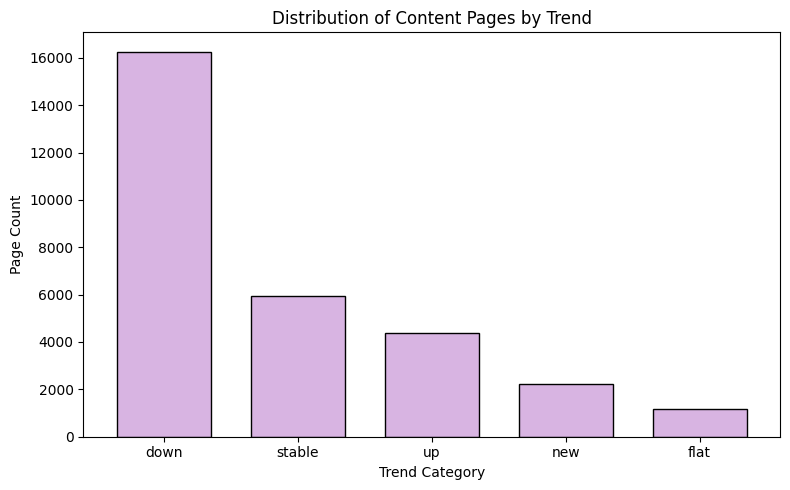

In [46]:
import matplotlib.pyplot as plt

# Count the number of pages in each trend category
trend_counts = df["trend_direction"].value_counts()

# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 5))

trend_counts.plot(
    kind="bar",
    ax=ax,
    color="#D8B4E2",
    edgecolor="black",
    width=0.7
)

# Add chart labels
ax.set_title("Distribution of Content Pages by Trend")
ax.set_xlabel("Trend Category")
ax.set_ylabel("Page Count")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

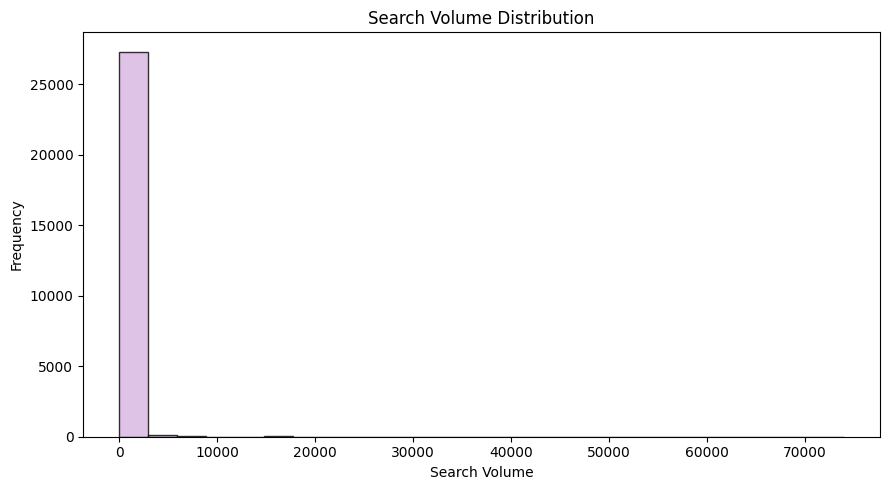

In [47]:
# Remove missing values from the search volume column
search_data = df["search_volume"].dropna()

# Create the histogram
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    search_data,
    bins=25,
    color="#D8B4E2",
    edgecolor="black",
    alpha=0.8
)

# Add labels and title
ax.set_title("Search Volume Distribution")
ax.set_xlabel("Search Volume")
ax.set_ylabel("Frequency")

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

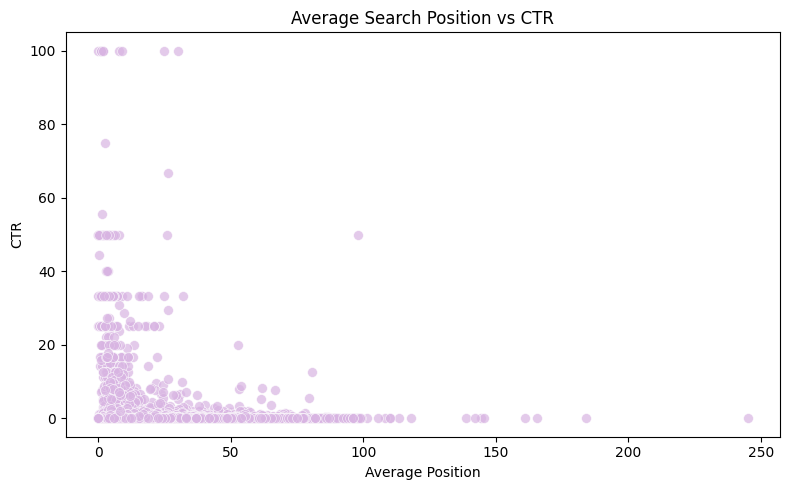

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["avg_position"],
    df["ctr"],
    color="#D8B4E2",   # Soft Lavender
    alpha=0.7,
    s=50,              # Slightly larger dots
    edgecolors="white",
    linewidth=0.5
)

plt.title("Average Search Position vs CTR")
plt.xlabel("Average Position")
plt.ylabel("CTR")

plt.tight_layout()
plt.show()


## 5. Why ML beats a fixed rule here


A fixed rule, such as refreshing every page with fewer than 1000 views, ignores many important factors like engagement, CTR, content age, and traffic trends.

Machine learning can learn complex relationships between multiple features and prioritize pages more accurately. This helps content teams make better decisions based on historical patterns instead of relying on simple thresholds.

In [49]:
print("Machine Learning considers multiple features together, making it more effective than a fixed rule.")

Machine Learning considers multiple features together, making it more effective than a fixed rule.


In [50]:
# Numerical columns selected for correlation analysis
selected_columns = [
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "trend_pct"
]

# Calculate the correlation matrix
correlation_matrix = df[selected_columns].corr()

# Display the correlation matrix
correlation_matrix

,search_volume,ctr,avg_position,engagement_rate,scroll_rate,trend_pct
search_volume,1.000000,-0.003430,0.045354,-0.010146,-0.013808,0.002515
ctr,-0.003430,1.000000,-0.072590,0.096903,0.012955,0.007968
avg_position,0.045354,-0.072590,1.000000,-0.017926,-0.039757,0.047248
engagement_rate,-0.010146,0.096903,-0.017926,1.000000,0.162611,0.008412
scroll_rate,-0.013808,0.012955,-0.039757,0.162611,1.000000,0.001868
trend_pct,0.002515,0.007968,0.047248,0.008412,0.001868,1.000000


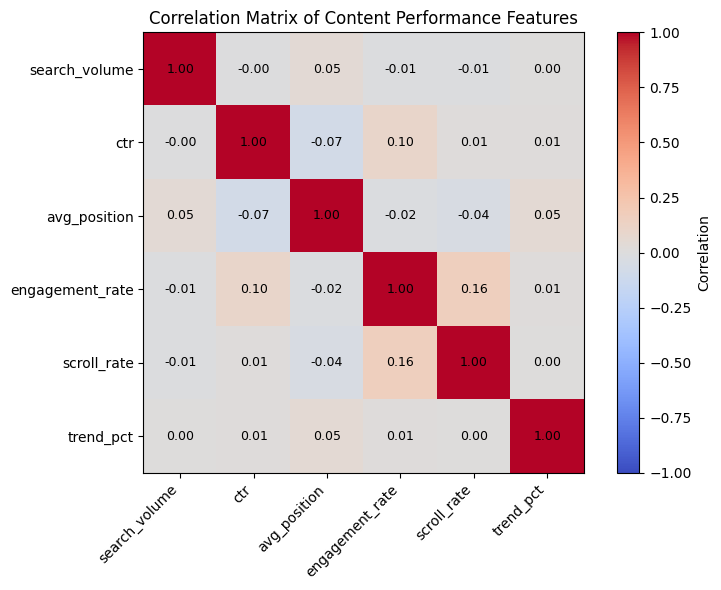

In [51]:
# Select only the required features
corr = df[features].corr()

# Create figure
plt.figure(figsize=(8, 6))

# Display correlation matrix
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# Add color bar
plt.colorbar(label="Correlation")

# Add axis labels
plt.xticks(
    ticks=np.arange(len(features)),
    labels=features,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(features)),
    labels=features
)

# Display correlation values inside each cell
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

# Add title
plt.title("Correlation Matrix of Content Performance Features")

plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.